In [104]:
# importing packages and styling plots
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

import scienceplots 
plt.style.use(["science", "grid"])
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "figure.titlesize": 15,
})

In [ ]:
# part 2 - KNN
# load MNIST dataset

pixels = np.loadtxt("data/MNIST-5-6-Subset.txt")
labels = np.loadtxt("data/MNIST-5-6-Subset-Labels.txt")

# prepare for KNN
d = 784
X = pixels.reshape(d, 1877, order="F").astype(float)
y = labels.astype(int)
y = np.where(y==5,-1,1)

# visualize m=50 numbers
indices = np.arange(50)

fig, axes = plt.subplots(5, 10, figsize=(8, 7))

for ax, i in zip(axes.ravel(), indices):
    image = X[:, i].reshape(28, 28, order="F")

    ax.imshow(image, cmap="gray")
    ax.axis("off")
    ax.set_title(f"{y[i]}", pad=1)

plt.subplots_adjust(
    wspace=0.1,
    hspace=-0.5
)

fig.savefig(
    "output/digits_visualized.png",
    dpi=300,
    bbox_inches="tight",
)

In [ ]:
# knn function
def knn(training_points, training_labels, test_points, test_labels, seed=56):

    rng = np.random.default_rng(seed)

    ones = lambda q: np.ones(q).reshape(q,1)
    
    m = len(training_labels) # number of train datapoints
    n = len(test_labels) # number of test datapoints

    # distance matrix
    train_sqn  = np.diag(training_points.T @ training_points).reshape(m,1)
    test_sqn   = np.diag(test_points.T @ test_points).reshape(n,1)
    trainTtest = training_points.T @ test_points

    D = (
        train_sqn @ ones(n).T 
        - 2*trainTtest 
        + ones(m) @ test_sqn.T
    )

    # distance sorting
    D_sort_index  = np.argsort(D,axis=0)
    sorted_labels = training_labels[D_sort_index]

    # predictions
    sorted_labels_cumsum= sorted_labels.cumsum(axis=0)
    pred = np.sign(sorted_labels_cumsum)

    # randomly assign -1 or 1 wherever there is a tie
    ties = pred == 0
    pred[ties] = rng.choice([-1, 1], size=ties.sum())

    # predictions errors and average errors
    error     = pred != test_labels
    avg_error = np.mean(error,axis=1)
    
    return avg_error

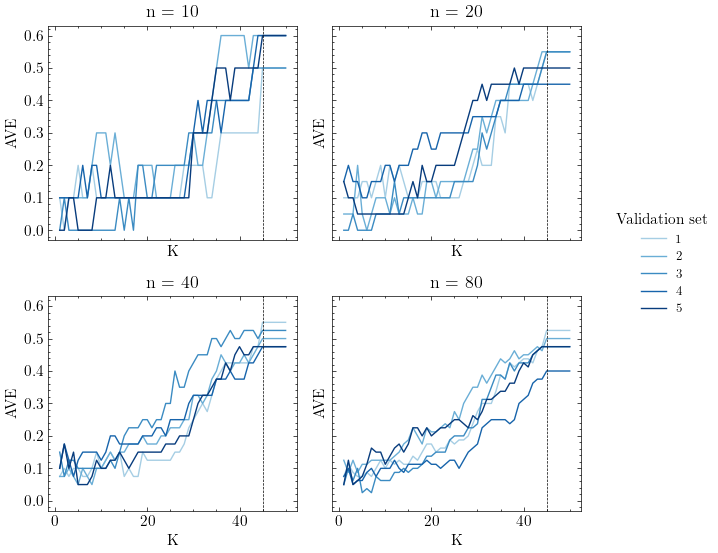

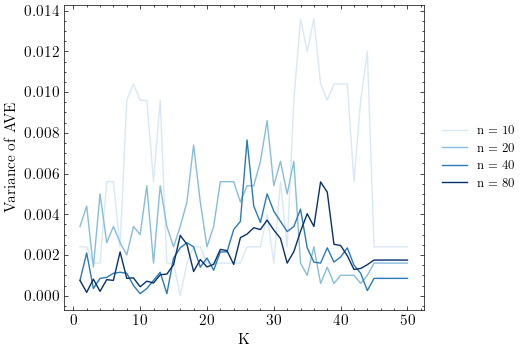

In [ ]:
# plotting 
m = 50 # number of training points
n_values = [10, 20, 40, 80] # validation set sizes
K_values = np.arange(1, m + 1) 
 
training_points = X[:, :m] 
training_labels = y[:m] 

validation_colors = plt.cm.Blues(np.linspace(0.35, 0.95, 5))
variance_colors = plt.cm.Blues(np.linspace(0.15, 1.0, len(n_values)))

# fig 1: four plots with five validation-error lines each 
fig_errors, axes = plt.subplots( 
    2, 2, 
    figsize=(7, 6), 
    sharex=True, 
    sharey=True 
) 
 
axes = axes.ravel() 
 
# fig 2: four variance lines 
fig_variance, ax_variance = plt.subplots(figsize=(5.5, 3.75)) 

j=0
for ax, n in zip(axes, n_values): 
 
    # rows are K, columns are validation sets 
    avg_errors_matrix = np.empty((m, 5)) 
 
    for i in range(5): 
        start = m + i * n 
        end = m + (i + 1) * n 
 
        test_points = X[:, start:end] 
        test_labels = y[start:end] 
 
        avg_errors = knn( 
            training_points, 
            training_labels, 
            test_points, 
            test_labels 
        ) 
 
        avg_errors_matrix[:, i] = avg_errors 
 
        ax.plot( 
            K_values, 
            avg_errors, 
            label=f"{i + 1}",
            color=validation_colors[i]
        ) 
 
    ax.set_title(f"n = {n}") 
    ax.set_xlabel("K") 
    ax.set_ylabel("AVE") 
    ax.axvline(x=45, linestyle="--", color="black", lw=0.5)
    ax.grid() 
 
    # variance across the five validation sets
    variance = avg_errors_matrix.var(axis=1) 
 
    ax_variance.plot( 
        K_values, 
        variance, 
        label=f"n = {n}",
        color=variance_colors[j]
    ) 
    j+=1


# shared legend for small plots
handles, labels = axes[0].get_legend_handles_labels()

fig_errors.legend(
    handles,
    labels,
    title="Validation set",
    loc="center left",
    bbox_to_anchor=(0.88, 0.5),
    frameon=False
)

# leave room on the right for the legend
fig_errors.tight_layout(
    rect=[0, 0, 0.87, 0.96]
) 

# fig_errors.suptitle( 
#     "K-NN validation errors for different validation-set sizes" 
# ) 

fig_errors.savefig(
    "output/knn_validation_errors.png",
    dpi=300,
    bbox_inches="tight"
)

# variance plot
ax_variance.set_xlabel("K") 
ax_variance.set_ylabel("Variance of AVE") 
# ax_variance.set_title("Variance across the five validation sets") 

ax_variance.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

ax_variance.grid() 
fig_variance.tight_layout() 

fig_variance.savefig(
    "output/variance_errors.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# part 3
# load PCB data and split into X and y
data = np.loadtxt('data/PCB.dt')

X_raw = data[:,0].astype(int)
X_design = np.column_stack(
    (np.ones(len(X_raw)), X_raw)
)

y_raw = data[:,1]
y = np.log(data[:,1])

In [ ]:
def reg(X,y):
    # assuming X is N x (k+1)

    # estimating the parameters
    b = (
        np.linalg.inv(X.T @ X) @ 
        X.T @ y
    )

    # calculating predicted PCB values
    y_pred = np.exp(X @ b)
    y_raw  = np.exp(y)

    # calculating MSE
    MSE = np.mean((y_raw-y_pred)**2)

    # calculating R^2
    R2 = 1 - MSE / np.sum((y_raw-np.mean(y_raw))**2)

    return b, MSE, R2

In [ ]:
b, MSE, R2 = reg(X_design,y)
print(b, MSE, R2)

[0.03147247 0.25912824] 34.83556116722034 0.9770361990414638


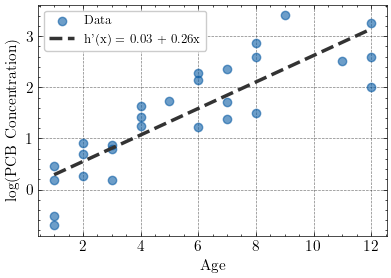

In [ ]:
hor = np.linspace(
    np.min(X_design[:,1]),
    np.max(X_design[:,1])
)
ver = b[0] + b[1]*hor

plt.figure(figsize=(4.5,3))
plt.scatter(X_raw, y, alpha=0.6)
plt.plot(hor, ver, ls="--", color=(0.2,0.2,0.2), lw=2.5)
plt.xlabel("Age")
plt.ylabel("$\log$(PCB Concentration)")
plt.legend(["Data", f"h'(x) = {b[0]:.2f} + {b[1]:.2f}x"])
plt.savefig(
    "output/PCB_regression.png",
    dpi=300, 
    bbox_inches="tight",
)
plt.show()

In [ ]:
# part 6: square root transformation of the age variable
X_design_6 = X_design.copy()
X_design_6[:,1] = np.sqrt(X_design_6[:,1])

b, MSE, R2 = reg(X_design_6,y)
print(b, MSE, R2)

hor = np.linspace(
    np.min(X_design[:,1]),
    np.max(X_design[:,1])
)
ver = b[0] + b[1]*np.sqrt(hor)

plt.figure(figsize=(4.5,3))
plt.scatter(X_raw, y, alpha=0.6)
plt.plot(hor, ver, ls="--", color=(0.2,0.2,0.2), lw=2.5)
plt.xlabel("Age")
plt.ylabel("log(PCB Concentration)")
plt.legend(["Data", rf"h'(x) = {b[0]:.2f} + {b[1]:.2f}$\sqrt{{x}}$"])
plt.savefig(
    "output/PCB_regression_sqrtx.png",
    dpi=300, 
    bbox_inches="tight",
)
plt.show()

SyntaxError: expected argument value expression (4276077864.py, line 16)